In [2]:
from models import VGG11_32, VDP_VGG11_32
from utils_vdp import gaussian_loss, dirichlet_loss, mc_nll
from layers import MySoftmax

import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from copy import deepcopy
from tqdm import tqdm
import torch.nn.functional as F


In [3]:
tt = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2, 0.2, 0.2, 0.1),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5071, 0.4867, 0.4408],
                     std=[0.2675, 0.2565, 0.2761])
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True,
                                       transform=tt)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True,
                                       transform=transforms.ToTensor())
testloader = torch.utils.data.DataLoader(testset, batch_size=128, shuffle=False, num_workers=2)


In [4]:
def dirichlet_loss(mu, sigma, targets, eps=1e-8, lambda_reg=0.01):
    """
    mu: [B, C] - predicted mean logits
    sigma: [B, C] - predicted variance logits (uncertainty)
    targets: [B] - ground truth labels
    lambda_reg: regularization weight
    """
    # Convert logits to probabilities
    #p = F.softmax(mu, dim=1)  # [B, C]
    
    # Better evidence calculation - inversely related to uncertainty
    evidence = mu / (sigma + eps)  # [B, C]
    
    # Dirichlet concentration parameters 
    alpha = evidence + 1  # avoid zero concentration
    
    # Compute alpha_0 (sum of all alpha parameters)
    alpha_0 = torch.sum(alpha, dim=1)  # [B]
    
    # Get target alphas
    target_oh = F.one_hot(targets, num_classes=mu.size(1)).float()  # [B, C]
    alpha_target = torch.sum(alpha * target_oh, dim=1)  # [B]
    
    # Main loss term - simplified approximation of Dirichlet negative log-likelihood
    main_loss = torch.log(alpha_0) - torch.log(alpha_target)
    
    # Regularization term to encourage low uncertainty for predicted class
    reg_loss = lambda_reg * torch.sum(mu * sigma, dim=1)

    # Total loss
    loss = main_loss + reg_loss
    
    return loss.mean()

def train_nn(model, trainloader, testloader, vdp=None, kl_factor=0.00001, lr=0.0001, epochs=10, device='cpu'):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    losses = []
    for _ in tqdm(range(epochs)):  # You can increase this
        model.train()
        running_loss = 0.0
        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            if not vdp:
                outputs = model(images)
                loss = criterion(outputs, labels)                
            elif vdp=="gaussian":
                mu, sigma, kl = model(images)
                mu, sigma = MySoftmax()(mu, sigma)
                loss = gaussian_loss(mu, sigma, labels) + kl_factor * kl
            elif vdp=="dirichlet":
                mu, sigma, kl = model(images)
                mu, sigma = MySoftmax()(mu, sigma)
                loss = dirichlet_loss(mu, sigma, labels) + kl_factor * kl
            elif vdp=="mc":
                mu, sigma, kl = model(images)
                loss = mc_nll(mu, sigma, labels) + kl_factor * kl
            
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        # Print average loss for each epoch
      #  print(f'Epoch {_+1}, Loss: {running_loss / len(trainloader)}')
        losses.append(running_loss)
    # Evaluation phase after training
    model.eval()

    correct = 0
    total = 0
    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)
        if not vdp:
            outputs = model(images)
        else:
            outputs, _, _ = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    accuracy_train = correct / total
    
    correct = 0
    total = 0
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        if not vdp:
            outputs = model(images)
        else:
            outputs, _, _ = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    accuracy_test = correct / total
    print(f"finished training with train acc {accuracy_train}, and test acc {accuracy_test}")
    return model, accuracy_test, accuracy_train, losses
    

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = VGG11_32(num_classes=10).to(device)
model_vdp = VDP_VGG11_32(num_classes=10)
model_vdp(torch.zeros((1,3,32,32)))
model_vdp = model_vdp.to(device)

100%|██████████| 150/150 [46:10<00:00, 18.47s/it]


finished training with train acc 0.90608, and test acc 0.342


100%|██████████| 150/150 [48:00<00:00, 19.20s/it]


finished training with train acc 0.44824, and test acc 0.1006


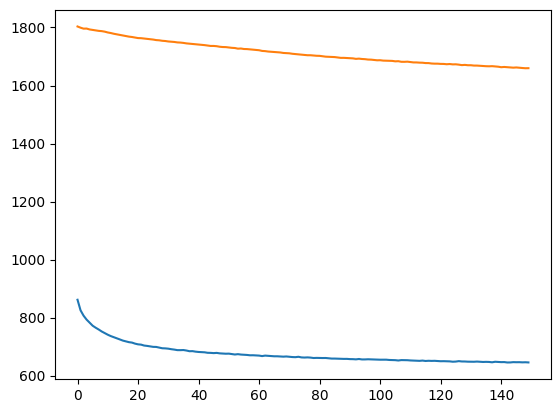

In [6]:
tt = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2, 0.2, 0.2, 0.1),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5071, 0.4867, 0.4408],
                     std=[0.2675, 0.2565, 0.2761])
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True,
                                       transform=tt)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True,
                                       transform=transforms.ToTensor())
testloader = torch.utils.data.DataLoader(testset, batch_size=128, shuffle=False, num_workers=2)

model_vdp = VDP_VGG11_32(num_classes=10)
model_vdp(next(iter(testloader))[0])
model_vdp = model_vdp.to(device)
model_diri, accuracy_test_diri, accuracy_train_diri, losses_diri = train_nn(deepcopy(model_vdp), trainloader, testloader, vdp="dirichlet", device=device, epochs=150)
torch.save(model_diri, "diri_cifar10")
plt.plot(losses_diri)

trainset = torchvision.datasets.CIFAR100(root='./data', train=True, download=True,
                                       transform=tt)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR100(root='./data', train=False, download=True,
                                       transform=transforms.ToTensor())
testloader = torch.utils.data.DataLoader(testset, batch_size=128, shuffle=False, num_workers=2)
model_vdp = VDP_VGG11_32(num_classes=100)
model_vdp(next(iter(testloader))[0])
model_vdp = model_vdp.to(device)
model_diri, accuracy_test_diri, accuracy_train_diri, losses_diri = train_nn(deepcopy(model_vdp), trainloader, testloader, vdp="dirichlet", device=device, epochs=150)
torch.save(model_diri, "diri_cifar100")
plt.plot(losses_diri)



In [5]:
model, accuracy_test, accuracy_train, losses = train_nn(deepcopy(model), trainloader, testloader, vdp=None, device=device)
#model_gaus, accuracy_test_gaus, accuracy_train_gaus, losses_gaus = train_nn(deepcopy(model_vdp), trainloader, testloader, vdp="gaussian", device=device)
model_diri, accuracy_test_diri, accuracy_train_diri, losses_diri = train_nn(deepcopy(model_vdp), trainloader, testloader, vdp="dirichlet", device=device)
model_mc, accuracy_test_mc, accuracy_train_mc, losses_mc = train_nn(deepcopy(model_vdp), trainloader, testloader, vdp="mc", device=device)

100%|██████████| 10/10 [02:21<00:00, 14.14s/it]


finished training with train acc 0.68374, and test acc 0.3023


100%|██████████| 10/10 [03:01<00:00, 18.19s/it]


finished training with train acc 0.62124, and test acc 0.3273


100%|██████████| 10/10 [02:59<00:00, 17.93s/it]


finished training with train acc 0.7257, and test acc 0.3741


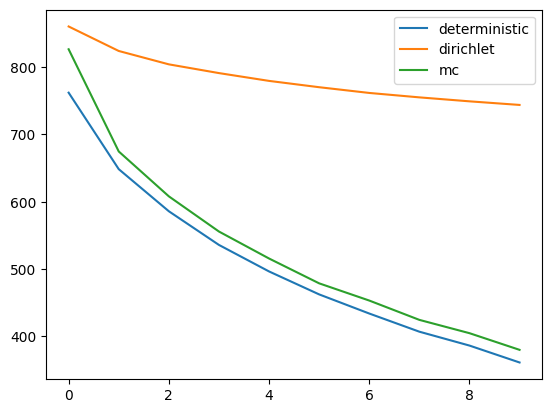

In [6]:
plt.plot(losses, label="deterministic")
#plt.plot(losses_gaus, label="gaussian")
plt.plot(losses_diri, label="dirichlet")
plt.plot(losses_mc, label="mc")
plt.legend()

In [7]:
import evaluate_models
ood = torchvision.datasets.SVHN(root='./data', download=True, transform=transforms.ToTensor())
oodloader = torch.utils.data.DataLoader(ood, batch_size=128, shuffle=False, num_workers=2)
evaluate_models.compare_two_models(model, model_mc, testloader, oodloader, 'cuda')

Evaluating models
Evaluating VDP model


Evaluating calibration
Evaluating Gaussian noise
{'max_output_auroc': np.float64(0.7174717835838215), 'max_output_aupr': np.float64(0.39077798011090026), 'max_output_fpr95': np.float64(0.9631161527226068), 'entropy_auroc': np.float64(0.6380284491584423), 'entropy_aupr': np.float64(0.2658961245752253), 'entropy_fpr95': np.float64(0.9866633905292327)} {'max_output_auroc': np.float64(0.6460733063051994), 'max_output_aupr': np.float64(0.44802404595081424), 'max_output_fpr95': np.float64(0.9930109068075406), 'mean_output_sigma_auroc': np.float64(0.7320250761019425), 'mean_output_sigma_aupr': np.float64(0.5093116568345311), 'mean_output_sigma_fpr95': np.float64(0.9757838841339395), 'max_output_sigma_auroc': np.float64(0.7553594796401709), 'max_output_sigma_aupr': np.float64(0.4904043553925409), 'max_output_sigma_fpr95': np.float64(0.8912458877649917), 'entropy_auroc': np.float64(0.5679731964180897), 'entropy_aupr': np.float64(0.33524970829579503), 'entropy_fpr95': np.float64(0.99325661711508

In [8]:
model_vdp = VDP_VGG11_32(num_classes=100)
model_vdp(next(iter(testloader))[0])
model_vdp.load_weights(model)

Shape mismatch at parameter 36. Expected shape torch.Size([100, 512]), got torch.Size([10, 512])


In [9]:
# Train from scratch
EPOCHS = 500
kl_factor = 0.00001

optimizer = optim.Adam(list(model_vdp.parameters())[1::2], lr=0.001)
model_vdp = model_vdp.to(device)

for epoch in range(EPOCHS):
    running_loss, running_kl, accuracy = 0.0, 0.0, 0.0
    for i, (images, labels) in enumerate(trainloader):
        images = images.to(device)
        labels = labels.to(device)
        # Forward pass
        mu, sigma, kl = model_vdp(images)
        mu, sigma = MySoftmax()(mu, sigma)
        loss = gaussian_loss(mu, sigma, labels) + kl_factor * kl
        
        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        running_kl += kl.item()
        accuracy += (mu.argmax(dim=1) == labels).float().sum().item()
    running_loss /= len(trainloader)
    running_kl /= len(trainloader)
    accuracy /= len(trainloader.dataset)
    print(running_loss, running_kl, accuracy)

-0.16708891063242617 881.0130774456521 0.0003


-0.16727568788449174 862.3672209054308 0.00026
-0.16738617747945858 851.201878228151 0.00034
-0.167457717535136 844.2001859464914 0.00022
-0.1675022708256836 839.6706630384831 0.00026
-0.1675320857626093 836.6836280920317 0.00042
-0.16755200587117763 834.6955037226762 0.00026
-0.16756512689620942 833.3716461884092 0.00022
-0.1675741252158304 832.4969601057984 0.00018
-0.16757894454099942 831.9280993371364 0.0003
-0.1675822121636642 831.5668670576247 0.00042
-0.16758496133262848 831.3447292162025 0.00024
-0.16758610346280706 831.213515649976 0.00028
-0.16758863216318437 831.1396584279092 0.00032
-0.16758903018806293 831.1003174452526 0.00038
-0.16758824176038317 831.080585918768 0.00026
-0.16758913769746375 831.071314038523 0.00038
-0.16758710447022374 831.0672154731458 0.00038
-0.16758884661033024 831.0655116400756 0.00024
-0.16758824046463003 831.0648265165441 0.00022
-0.16758900918923986 831.064569263507 0.00036
-0.16758881486437816 831.06449652084 0.0003
-0.16758745352325538 831.064

In [16]:
from torchvision.models import vgg11
from models import VDP_VGG11_224
a = vgg11(num_classes=10)
b = VDP_VGG11_224(num_classes=10)
b(torch.zeros((1,3,224,224)))

(tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]], grad_fn=<AddBackward0>),
 tensor([[1.1020, 1.1020, 1.1020, 1.1020, 1.1020, 1.1020, 1.1020, 1.1020, 1.1020,
          1.1020]], grad_fn=<NanToNumBackward0>),
 tensor(1243.2035, grad_fn=<AddBackward0>))

In [8]:
model_vdp2 = VDP_VGG11_32(num_classes=100)
model_vdp2(next(iter(testloader))[0])
model_vdp2.load_weights(model)
model_vdp2 = model_vdp2.to(device)

Parameters assigned successfully.


In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.metrics import roc_curve

# Assuming you have the following lists initialized outside the loop
metrics = {
    "max_logits_mu": {"correct": [], "incorrect": []},
    "mean_logits_mu": {"correct": [], "incorrect": []},
    "max_logits_sigma": {"correct": [], "incorrect": []},
    "mean_logits_sigma": {"correct": [], "incorrect": []},
    "max_mu": {"correct": [], "incorrect": []},
    "mean_sigma": {"correct": [], "incorrect": []},
    "max_sigma": {"correct": [], "incorrect": []},
    "entropy": {"correct": [], "incorrect": []},
}

# Evaluation loop
for i, (images, labels) in enumerate(testloader):
    images = images.to(device)
    labels = labels.to(device)
    
    logits_mu, logits_sigma, kl = model_vdp(images)
    mu, sigma = MySoftmax()(logits_mu, logits_sigma)  # Assuming MySoftmax computes probabilities
    
    correct_idx = mu.argmax(dim=1) == labels  # boolean mask for correct predictions
    
    # Collect values for correct predictions
    metrics["max_logits_mu"]["correct"].append(logits_mu[correct_idx].max(dim=1)[0].cpu().detach().numpy())
    metrics["mean_logits_mu"]["correct"].append(logits_mu[correct_idx].mean(dim=1).cpu().detach().numpy())
    
    metrics["max_logits_sigma"]["correct"].append(logits_sigma[correct_idx].max(dim=1)[0].cpu().detach().numpy())
    metrics["mean_logits_sigma"]["correct"].append(logits_sigma[correct_idx].mean(dim=1).cpu().detach().numpy())
    
    metrics["max_mu"]["correct"].append(mu[correct_idx].max(dim=1)[0].cpu().detach().numpy())
    metrics["max_sigma"]["correct"].append(sigma[correct_idx].max(dim=1)[0].cpu().detach().numpy())
    metrics["mean_sigma"]["correct"].append(sigma[correct_idx].mean(dim=1).cpu().detach().numpy())
    
    # Collect values for incorrect predictions
    metrics["max_logits_mu"]["incorrect"].append(logits_mu[~correct_idx].max(dim=1)[0].cpu().detach().numpy())
    metrics["mean_logits_mu"]["incorrect"].append(logits_mu[~correct_idx].mean(dim=1).cpu().detach().numpy())
    
    metrics["max_logits_sigma"]["incorrect"].append(logits_sigma[~correct_idx].max(dim=1)[0].cpu().detach().numpy())
    metrics["mean_logits_sigma"]["incorrect"].append(logits_sigma[~correct_idx].mean(dim=1).cpu().detach().numpy())
    
    metrics["max_mu"]["incorrect"].append(mu[~correct_idx].max(dim=1)[0].cpu().detach().numpy())
    metrics["max_sigma"]["incorrect"].append(sigma[~correct_idx].max(dim=1)[0].cpu().detach().numpy())
    metrics["mean_sigma"]["incorrect"].append(sigma[~correct_idx].mean(dim=1).cpu().detach().numpy())
    
    # Calculate entropy for both correct and incorrect predictions
    entropy_correct = -torch.sum(mu[correct_idx] * torch.log(mu[correct_idx] + 1e-8), dim=1).cpu().detach().numpy()
    entropy_incorrect = -torch.sum(mu[~correct_idx] * torch.log(mu[~correct_idx] + 1e-8), dim=1).cpu().detach().numpy()

    metrics["entropy"]["correct"].append(entropy_correct)
    metrics["entropy"]["incorrect"].append(entropy_incorrect)

# Convert lists to numpy arrays for easier correlation computation
for metric in metrics:
    metrics[metric]["correct"] = np.concatenate(metrics[metric]["correct"])
    metrics[metric]["incorrect"] = np.concatenate(metrics[metric]["incorrect"])

# Combine correct and incorrect predictions for each metric
all_metrics = {metric: np.concatenate([metrics[metric]["correct"], metrics[metric]["incorrect"]]) for metric in metrics}

# Labels for correct/incorrect predictions (1 for correct, 0 for incorrect)
correct_labels = np.concatenate([np.ones(len(metrics["max_logits_mu"]["correct"])), np.zeros(len(metrics["max_logits_mu"]["incorrect"]))])

# Compute AUPR, AUROC, and FPR95 for each uncertainty metric
auroc = {}
aupr = {}
fpr95 = {}

for metric in all_metrics:
    # Compute AUROC
    auroc[metric] = roc_auc_score(correct_labels, all_metrics[metric])
    
    # Compute AUPR
    aupr[metric] = average_precision_score(correct_labels, all_metrics[metric])
    
    # Compute FPR95 (False Positive Rate at 95% True Positive Rate)
    fpr, tpr, thresholds = roc_curve(correct_labels, all_metrics[metric])
    fpr95_idx = np.argmax(tpr >= 0.95)  # Find index where TPR >= 95%
    fpr95[metric] = fpr[fpr95_idx]

# Print the evaluation metrics
for metric in auroc:
    print(f'{metric} - AUROC: {auroc[metric]:.4f}, AUPR: {aupr[metric]:.4f}, FPR95: {fpr95[metric]:.4f}')

# Plot histograms
fig, axs = plt.subplots(3, 3, figsize=(20, 15))

# Plot each metric
for i, (metric, data) in enumerate(metrics.items()):
    axs[i//3, i%3].hist(data["correct"], bins=30, alpha=0.7, label='Correct')
    axs[i//3, i%3].hist(data["incorrect"], bins=30, alpha=0.7, label='Incorrect')
    axs[i//3, i%3].set_title(f'{metric} (correct vs incorrect)')
    axs[i//3, i%3].legend()

# Hide last subplot (empty)
axs[2, 2].axis('off')

plt.tight_layout()
plt.show()


Correlation between max_logits_mu and correctness: 0.38993245613572636
Correlation between mean_logits_mu and correctness: -0.2460221637451972
Correlation between max_logits_sigma and correctness: 0.2735682780135094
Correlation between mean_logits_sigma and correctness: 0.27371639394249053
Correlation between max_mu and correctness: 0.3979841610244313
Correlation between mean_sigma and correctness: -0.37011840194270335
Correlation between max_sigma and correctness: -0.3837320394659211
Correlation between entropy and correctness: -0.4285730545149354


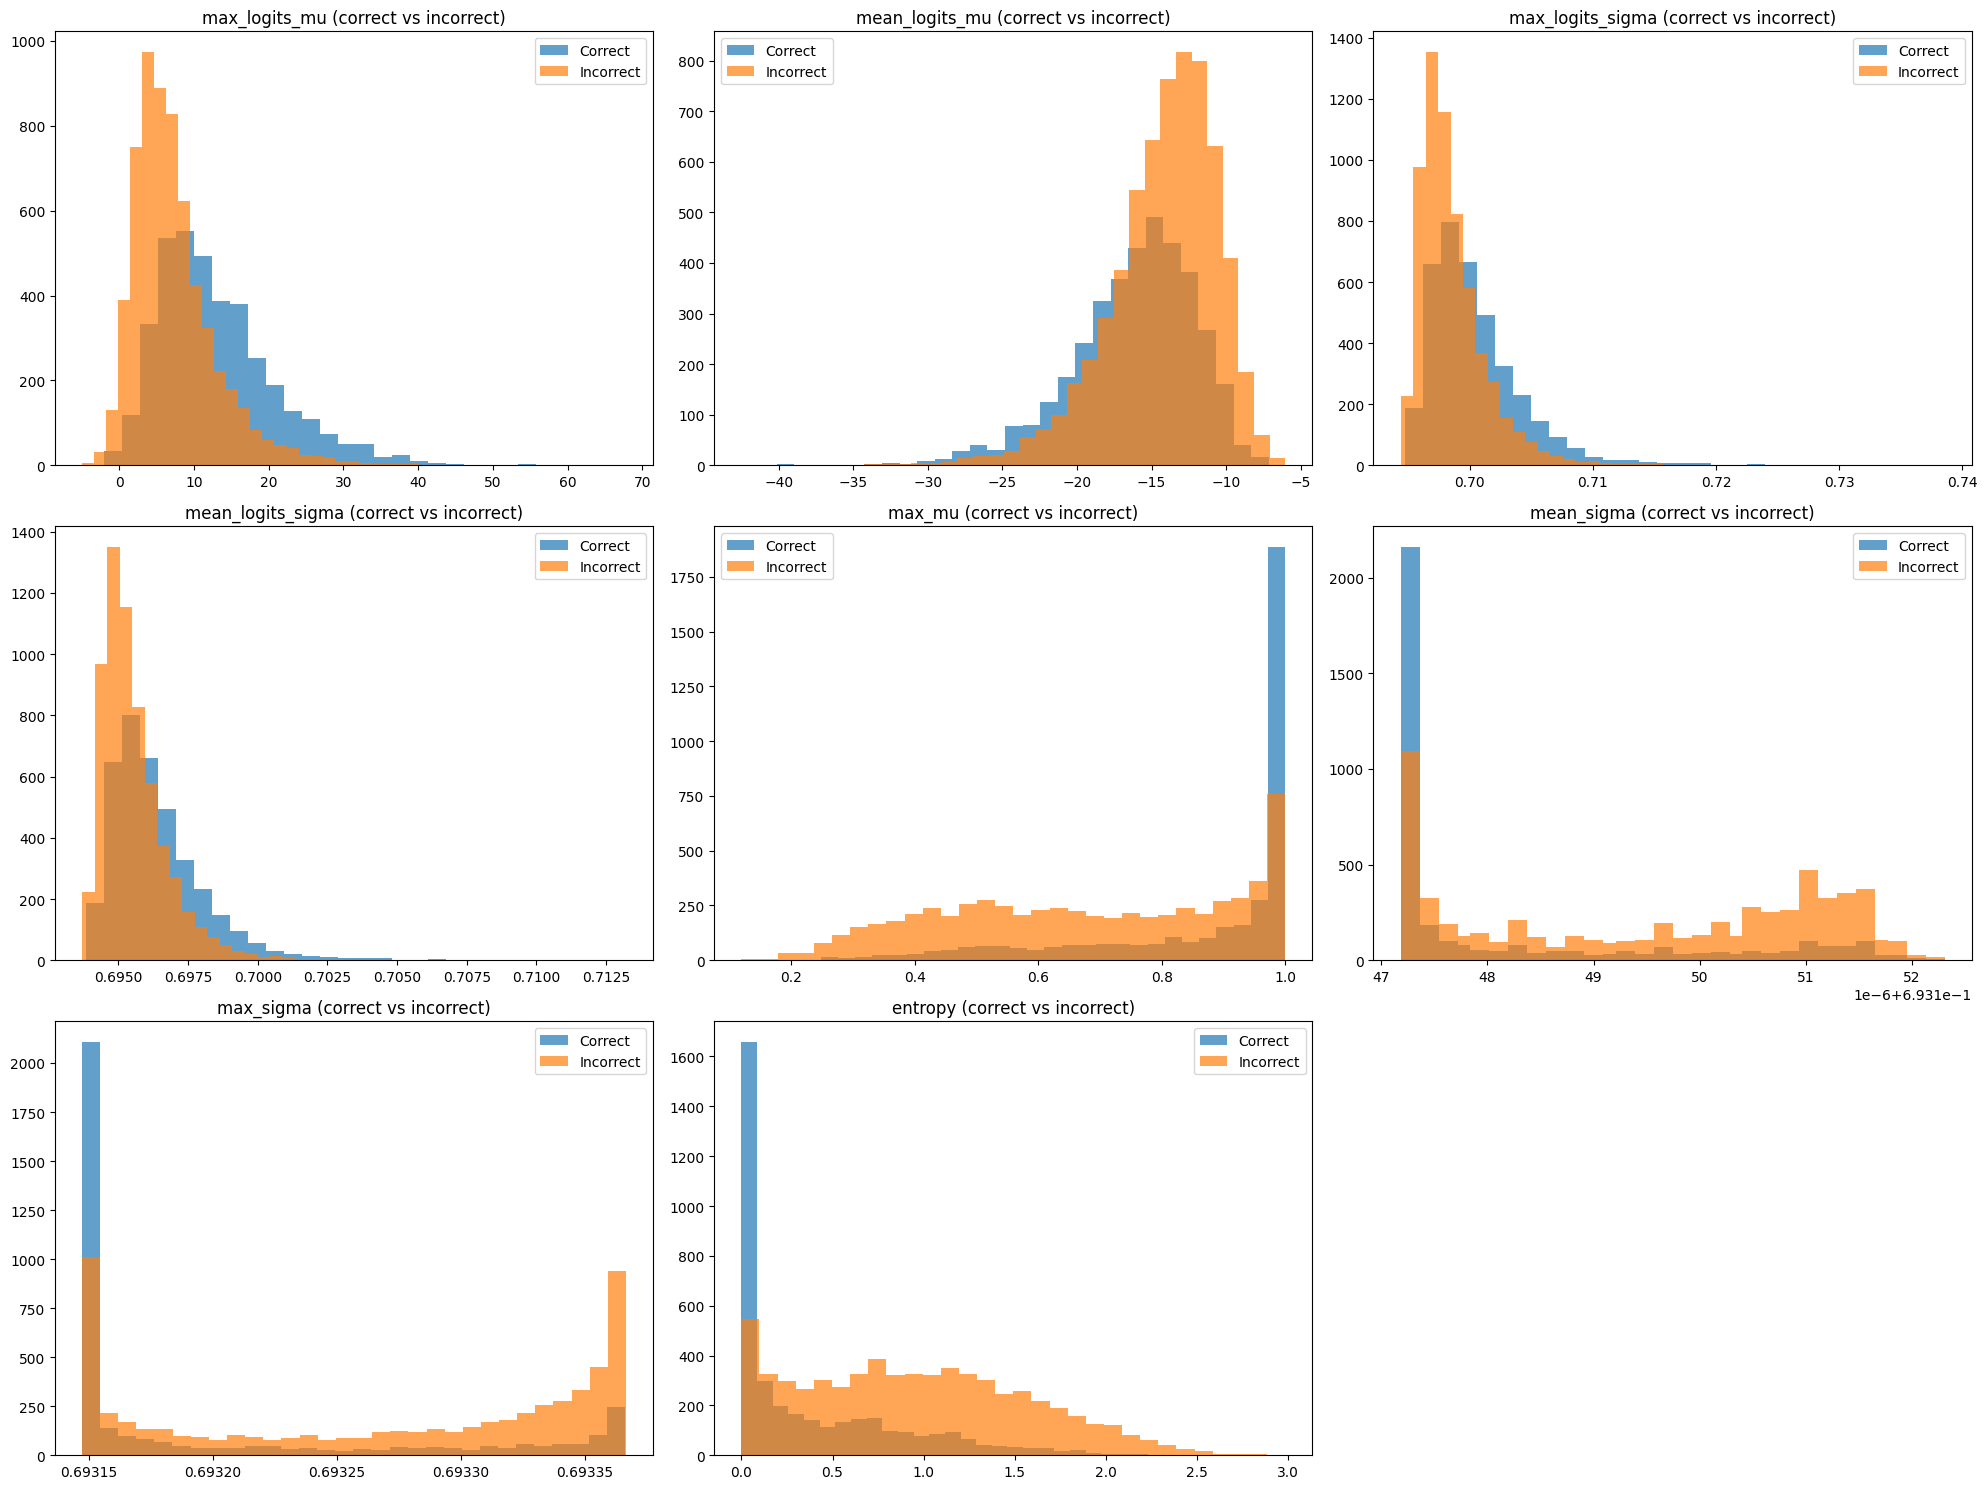

In [9]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr

# Assuming you have the following lists initialized outside the loop
metrics = {
    "max_logits_mu": {"correct": [], "incorrect": []},
    "mean_logits_mu": {"correct": [], "incorrect": []},
    "max_logits_sigma": {"correct": [], "incorrect": []},
    "mean_logits_sigma": {"correct": [], "incorrect": []},
    "max_mu": {"correct": [], "incorrect": []},
    "mean_sigma": {"correct": [], "incorrect": []},
    "max_sigma": {"correct": [], "incorrect": []},
    "entropy": {"correct": [], "incorrect": []},
    }

# Evaluation loop
for i, (images, labels) in enumerate(testloader):
    images = images.to(device)
    labels = labels.to(device)
    
    logits_mu, logits_sigma, kl = model_vdp2(images)
    mu, sigma = MySoftmax()(logits_mu, logits_sigma)  # Assuming MySoftmax computes probabilities
    
    correct_idx = mu.argmax(dim=1) == labels  # boolean mask for correct predictions
    
    # Collect values for correct predictions
    metrics["max_logits_mu"]["correct"].append(logits_mu[correct_idx].max(dim=1)[0].cpu().detach().numpy())
    metrics["mean_logits_mu"]["correct"].append(logits_mu[correct_idx].mean(dim=1).cpu().detach().numpy())
    
    metrics["max_logits_sigma"]["correct"].append(logits_sigma[correct_idx].max(dim=1)[0].cpu().detach().numpy())
    metrics["mean_logits_sigma"]["correct"].append(logits_sigma[correct_idx].mean(dim=1).cpu().detach().numpy())
    
    metrics["max_mu"]["correct"].append(mu[correct_idx].max(dim=1)[0].cpu().detach().numpy())

    metrics["max_sigma"]["correct"].append(sigma[correct_idx].max(dim=1)[0].cpu().detach().numpy())
    metrics["mean_sigma"]["correct"].append(sigma[correct_idx].mean(dim=1).cpu().detach().numpy())
    
    
    # Collect values for incorrect predictions
    metrics["max_logits_mu"]["incorrect"].append(logits_mu[~correct_idx].max(dim=1)[0].cpu().detach().numpy())
    metrics["mean_logits_mu"]["incorrect"].append(logits_mu[~correct_idx].mean(dim=1).cpu().detach().numpy())
    
    metrics["max_logits_sigma"]["incorrect"].append(logits_sigma[~correct_idx].max(dim=1)[0].cpu().detach().numpy())
    metrics["mean_logits_sigma"]["incorrect"].append(logits_sigma[~correct_idx].mean(dim=1).cpu().detach().numpy())
    
    metrics["max_mu"]["incorrect"].append(mu[~correct_idx].max(dim=1)[0].cpu().detach().numpy())

    metrics["max_sigma"]["incorrect"].append(sigma[~correct_idx].max(dim=1)[0].cpu().detach().numpy())
    metrics["mean_sigma"]["incorrect"].append(sigma[~correct_idx].mean(dim=1).cpu().detach().numpy())
    
    entropy_correct = -torch.sum(mu[correct_idx] * torch.log(mu[correct_idx] + 1e-8), dim=1).cpu().detach().numpy()
    entropy_incorrect = -torch.sum(mu[~correct_idx] * torch.log(mu[~correct_idx] + 1e-8), dim=1).cpu().detach().numpy()

    metrics["entropy"]["correct"].append(entropy_correct)
    metrics["entropy"]["incorrect"].append(entropy_incorrect)

# Convert lists to numpy arrays for easier correlation computation
for metric in metrics:
    metrics[metric]["correct"] = np.concatenate(metrics[metric]["correct"])
    metrics[metric]["incorrect"] = np.concatenate(metrics[metric]["incorrect"])

# Combine correct and incorrect predictions for each metric
all_metrics = {metric: np.concatenate([metrics[metric]["correct"], metrics[metric]["incorrect"]]) for metric in metrics}

# Labels for correct/incorrect predictions (1 for correct, 0 for incorrect)
correct_labels = np.concatenate([np.ones(len(metrics["max_logits_mu"]["correct"])), np.zeros(len(metrics["max_logits_mu"]["incorrect"]))])

# Compute Pearson correlation coefficients for each criterion
correlations = {}
for metric in all_metrics:
    correlations[metric] = pearsonr(all_metrics[metric], correct_labels)[0]

# Print the correlations
for metric, corr in correlations.items():
    print(f'Correlation between {metric} and correctness: {corr}')

# Plot histograms
fig, axs = plt.subplots(3, 3, figsize=(20, 15))

# Plot each metric
for i, (metric, data) in enumerate(metrics.items()):
    axs[i//3, i%3].hist(data["correct"], bins=30, alpha=0.7, label='Correct')
    axs[i//3, i%3].hist(data["incorrect"], bins=30, alpha=0.7, label='Incorrect')
    axs[i//3, i%3].set_title(f'{metric} (correct vs incorrect)')
    axs[i//3, i%3].legend()

# Hide last subplot (empty)
axs[2, 2].axis('off')

plt.tight_layout()
plt.show()


Correlation between max_logits_mu and correctness: 0.38993245613572636
Correlation between mean_logits_mu and correctness: -0.2460221637451972
Correlation between max_logits_sigma and correctness: 0.2738696885100327
Correlation between mean_logits_sigma and correctness: 0.27388346072245606
Correlation between max_mu and correctness: 0.3979841610244313
Correlation between mean_sigma and correctness: -0.3702612654950399
Correlation between max_sigma and correctness: -0.3838942879864192
Correlation between entropy and correctness: -0.4285730545149354


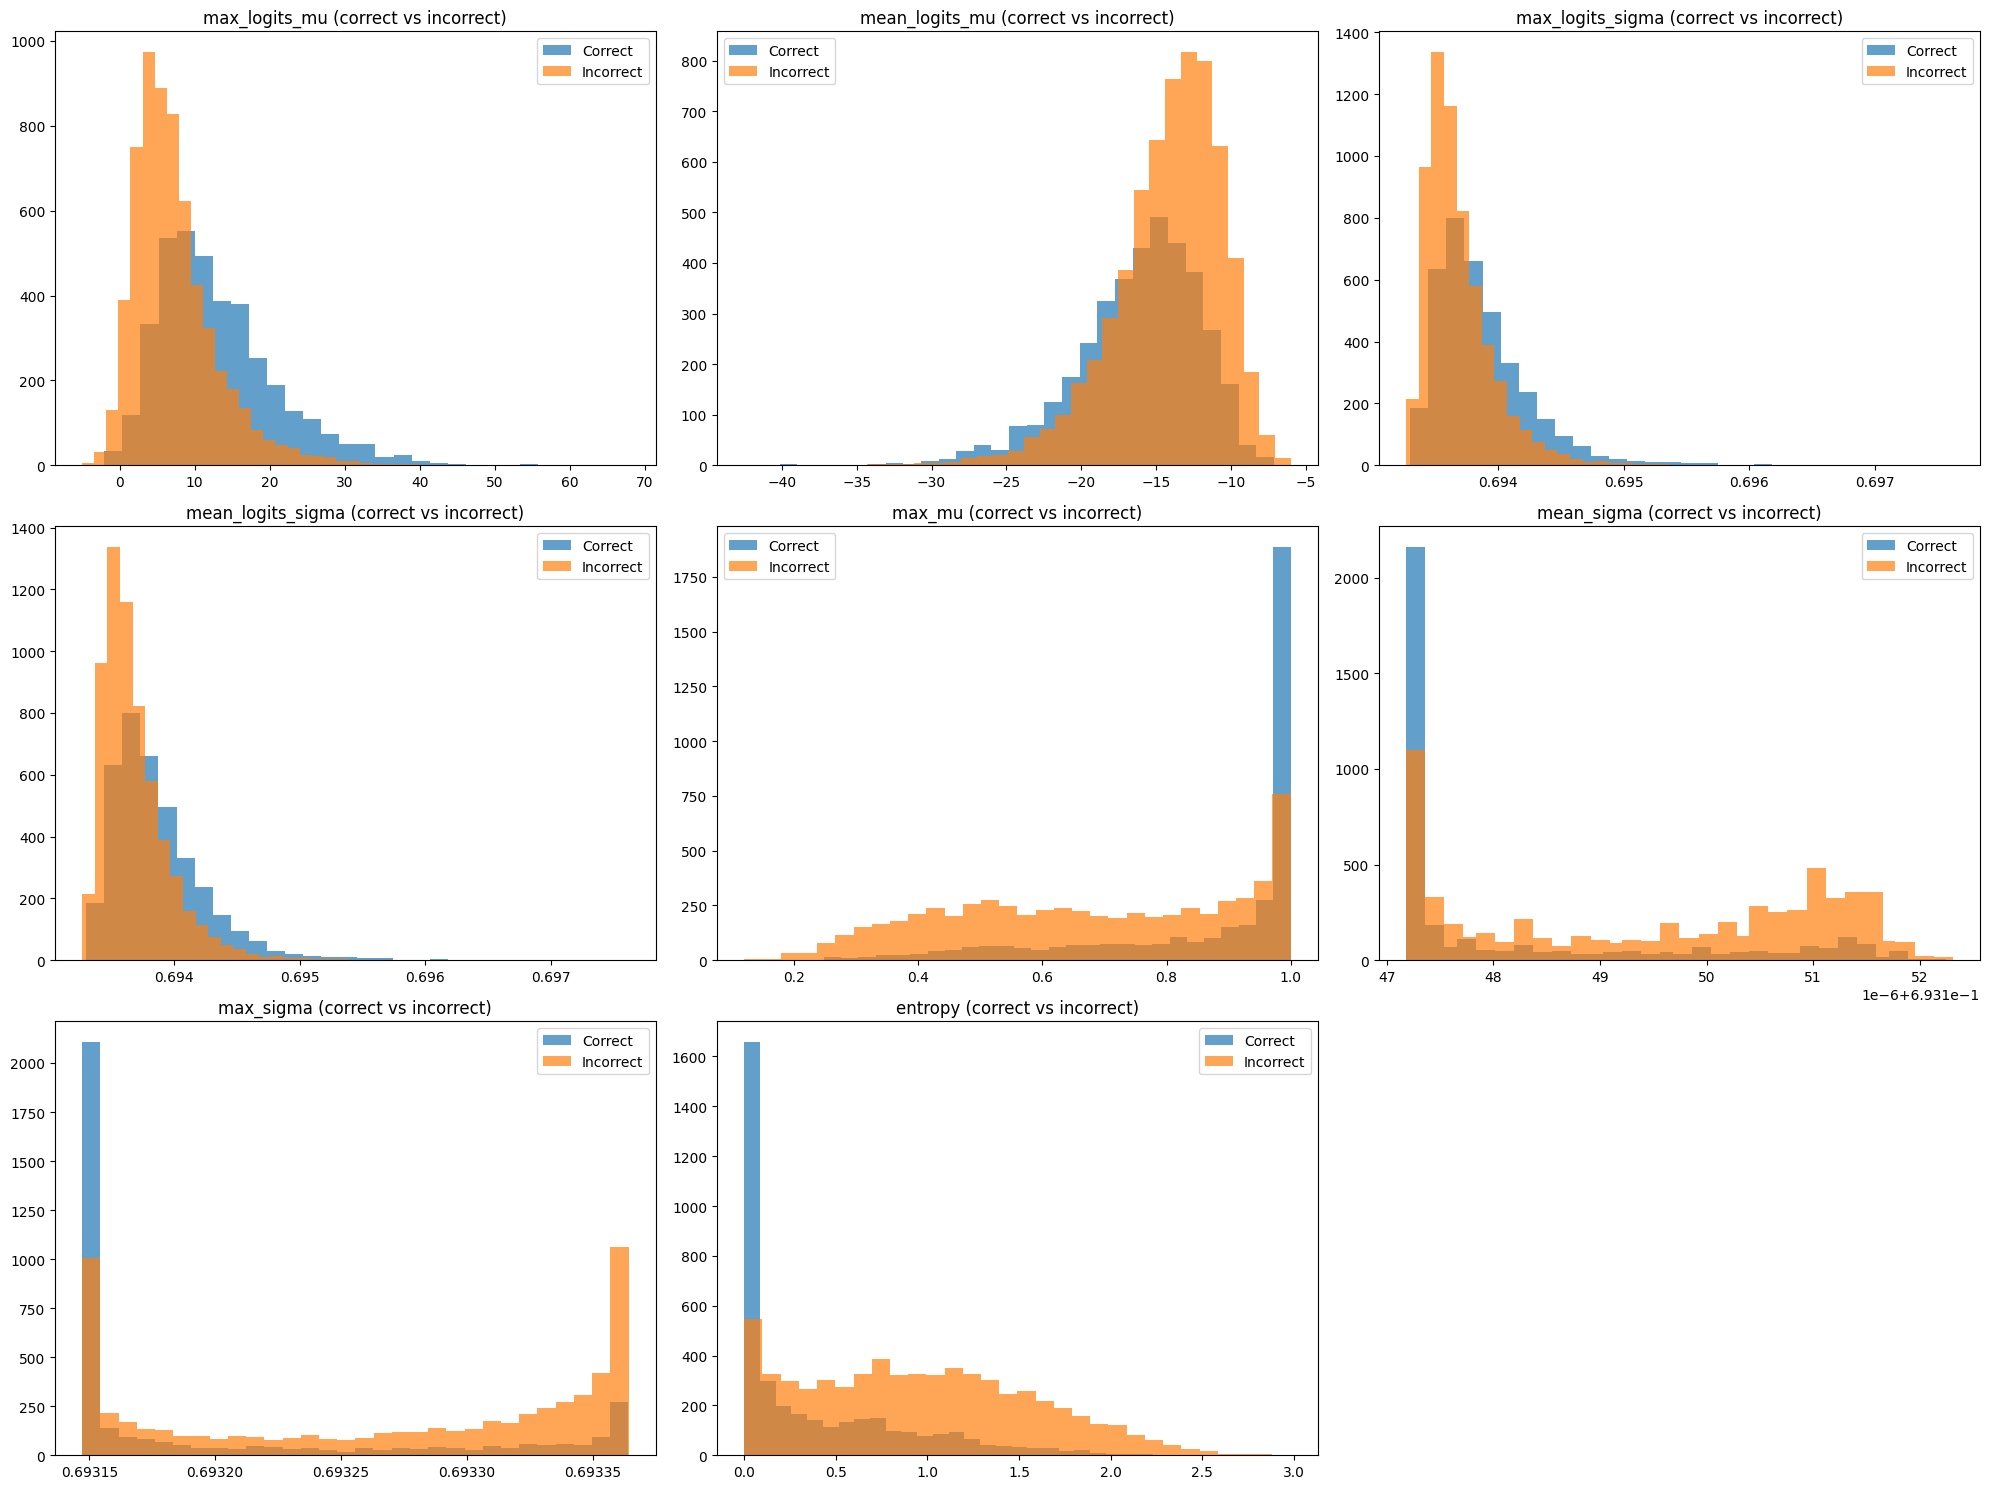

In [10]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr

# Assuming you have the following lists initialized outside the loop
metrics = {
    "max_logits_mu": {"correct": [], "incorrect": []},
    "mean_logits_mu": {"correct": [], "incorrect": []},
    "max_logits_sigma": {"correct": [], "incorrect": []},
    "mean_logits_sigma": {"correct": [], "incorrect": []},
    "max_mu": {"correct": [], "incorrect": []},
    "mean_sigma": {"correct": [], "incorrect": []},
    "max_sigma": {"correct": [], "incorrect": []},
    "entropy": {"correct": [], "incorrect": []},
    }

# Evaluation loop
for i, (images, labels) in enumerate(testloader):
    images = images.to(device)
    labels = labels.to(device)
    
    logits_mu, logits_sigma, kl = model_vdp(images)
    mu, sigma = MySoftmax()(logits_mu, logits_sigma)  # Assuming MySoftmax computes probabilities
    
    correct_idx = mu.argmax(dim=1) == labels  # boolean mask for correct predictions
    
    # Collect values for correct predictions
    metrics["max_logits_mu"]["correct"].append(logits_mu[correct_idx].max(dim=1)[0].cpu().detach().numpy())
    metrics["mean_logits_mu"]["correct"].append(logits_mu[correct_idx].mean(dim=1).cpu().detach().numpy())
    
    metrics["max_logits_sigma"]["correct"].append(logits_sigma[correct_idx].max(dim=1)[0].cpu().detach().numpy())
    metrics["mean_logits_sigma"]["correct"].append(logits_sigma[correct_idx].mean(dim=1).cpu().detach().numpy())
    
    metrics["max_mu"]["correct"].append(mu[correct_idx].max(dim=1)[0].cpu().detach().numpy())

    metrics["max_sigma"]["correct"].append(sigma[correct_idx].max(dim=1)[0].cpu().detach().numpy())
    metrics["mean_sigma"]["correct"].append(sigma[correct_idx].mean(dim=1).cpu().detach().numpy())
    
    
    # Collect values for incorrect predictions
    metrics["max_logits_mu"]["incorrect"].append(logits_mu[~correct_idx].max(dim=1)[0].cpu().detach().numpy())
    metrics["mean_logits_mu"]["incorrect"].append(logits_mu[~correct_idx].mean(dim=1).cpu().detach().numpy())
    
    metrics["max_logits_sigma"]["incorrect"].append(logits_sigma[~correct_idx].max(dim=1)[0].cpu().detach().numpy())
    metrics["mean_logits_sigma"]["incorrect"].append(logits_sigma[~correct_idx].mean(dim=1).cpu().detach().numpy())
    
    metrics["max_mu"]["incorrect"].append(mu[~correct_idx].max(dim=1)[0].cpu().detach().numpy())

    metrics["max_sigma"]["incorrect"].append(sigma[~correct_idx].max(dim=1)[0].cpu().detach().numpy())
    metrics["mean_sigma"]["incorrect"].append(sigma[~correct_idx].mean(dim=1).cpu().detach().numpy())
    
    entropy_correct = -torch.sum(mu[correct_idx] * torch.log(mu[correct_idx] + 1e-8), dim=1).cpu().detach().numpy()
    entropy_incorrect = -torch.sum(mu[~correct_idx] * torch.log(mu[~correct_idx] + 1e-8), dim=1).cpu().detach().numpy()

    metrics["entropy"]["correct"].append(entropy_correct)
    metrics["entropy"]["incorrect"].append(entropy_incorrect)

# Convert lists to numpy arrays for easier correlation computation
for metric in metrics:
    metrics[metric]["correct"] = np.concatenate(metrics[metric]["correct"])
    metrics[metric]["incorrect"] = np.concatenate(metrics[metric]["incorrect"])

# Combine correct and incorrect predictions for each metric
all_metrics = {metric: np.concatenate([metrics[metric]["correct"], metrics[metric]["incorrect"]]) for metric in metrics}

# Labels for correct/incorrect predictions (1 for correct, 0 for incorrect)
correct_labels = np.concatenate([np.ones(len(metrics["max_logits_mu"]["correct"])), np.zeros(len(metrics["max_logits_mu"]["incorrect"]))])

# Compute Pearson correlation coefficients for each criterion
correlations = {}
for metric in all_metrics:
    correlations[metric] = pearsonr(all_metrics[metric], correct_labels)[0]

# Print the correlations
for metric, corr in correlations.items():
    print(f'Correlation between {metric} and correctness: {corr}')

# Plot histograms
fig, axs = plt.subplots(3, 3, figsize=(20, 15))

# Plot each metric
for i, (metric, data) in enumerate(metrics.items()):
    axs[i//3, i%3].hist(data["correct"], bins=30, alpha=0.7, label='Correct')
    axs[i//3, i%3].hist(data["incorrect"], bins=30, alpha=0.7, label='Incorrect')
    axs[i//3, i%3].set_title(f'{metric} (correct vs incorrect)')
    axs[i//3, i%3].legend()

# Hide last subplot (empty)
axs[2, 2].axis('off')

plt.tight_layout()
plt.show()


Correlation between max logits and correctness: 0.4040400943025116
Correlation between mean logits sigma and correctness: -0.3569023233704496
Correlation between max mu and correctness: 0.3826470991588029
Correlation between mean sigma and correctness: -0.3569023233704496
Correlation between entropy and correctness: -0.41541011941030564


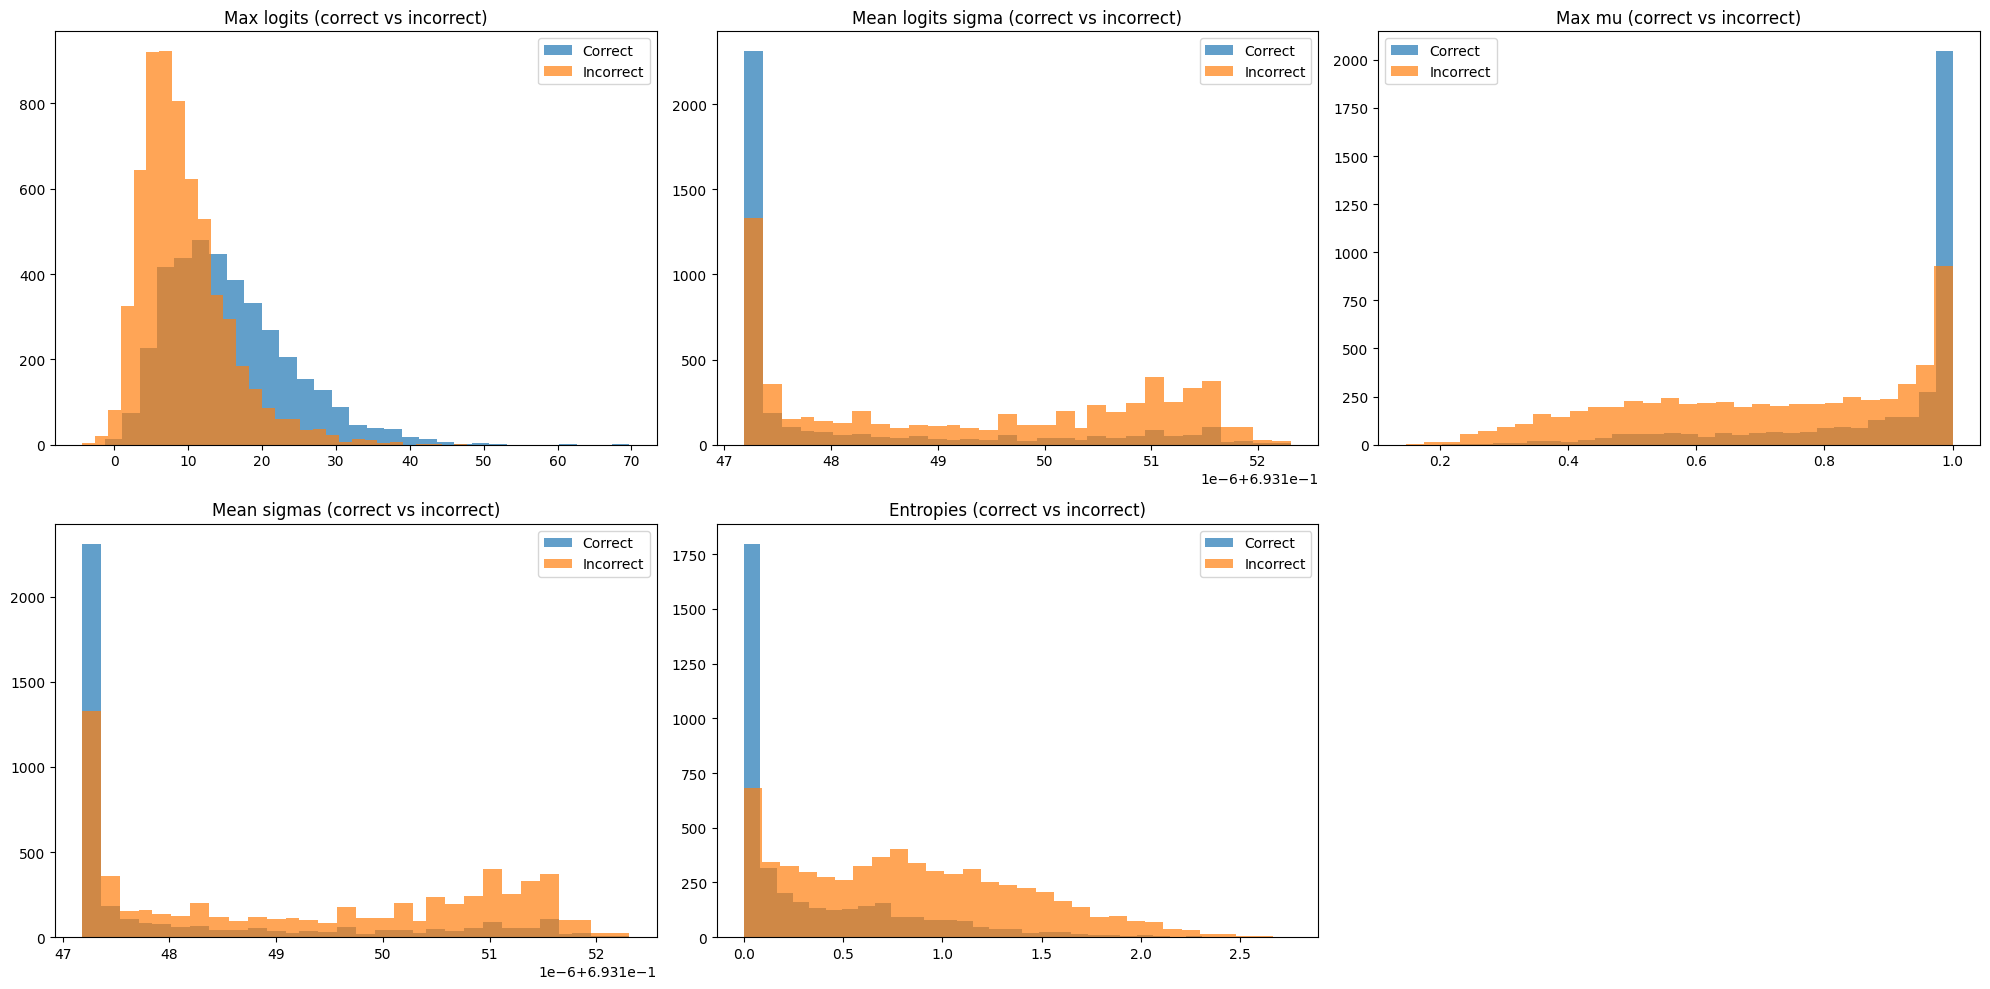

In [28]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr

# Assuming you have the following lists initialized outside the loop
max_logits_mus_correct = []
max_logits_mus_incorrect = []
mean_logits_sigmas_correct = []
mean_logits_sigmas_incorrect = []
max_mus_correct = []
max_mus_incorrect = []
mean_sigmas_correct = []
mean_sigmas_incorrect = []
entropies_correct = []
entropies_incorrect = []

# Evaluation loop
for i, (images, labels) in enumerate(testloader):
    images = images.to(device)
    labels = labels.to(device)
    
    logits_mu, logits_sigma, kl = model_vdp(images)
    mu, sigma = MySoftmax()(logits_mu, logits_sigma)  # Assuming MySoftmax computes probabilities
    
    correct_idx = mu.argmax(dim=1) == labels  # boolean mask for correct predictions
    
    # Collect values for correct predictions
    max_logits_mus_correct.append(logits_mu[correct_idx].max(dim=1)[0].cpu().detach().numpy())
    mean_logits_sigmas_correct.append(sigma[correct_idx].mean(dim=1).cpu().detach().numpy())
    max_mus_correct.append(mu[correct_idx].max(dim=1)[0].cpu().detach().numpy())
    mean_sigmas_correct.append(sigma[correct_idx].mean(dim=1).cpu().detach().numpy())
    
    # Collect values for incorrect predictions
    max_logits_mus_incorrect.append(logits_mu[~correct_idx].max(dim=1)[0].cpu().detach().numpy())
    mean_logits_sigmas_incorrect.append(sigma[~correct_idx].mean(dim=1).cpu().detach().numpy())
    max_mus_incorrect.append(mu[~correct_idx].max(dim=1)[0].cpu().detach().numpy())
    mean_sigmas_incorrect.append(sigma[~correct_idx].mean(dim=1).cpu().detach().numpy())
    
    # Calculate entropy for both correct and incorrect predictions
    entropy_correct = -torch.sum(mu[correct_idx] * torch.log(mu[correct_idx] + 1e-8), dim=1).cpu().detach().numpy()
    entropy_incorrect = -torch.sum(mu[~correct_idx] * torch.log(mu[~correct_idx] + 1e-8), dim=1).cpu().detach().numpy()

    entropies_correct.append(entropy_correct)
    entropies_incorrect.append(entropy_incorrect)

# Convert lists to numpy arrays for easier correlation computation
max_logits_mus_correct = np.concatenate(max_logits_mus_correct)
max_logits_mus_incorrect = np.concatenate(max_logits_mus_incorrect)
mean_logits_sigmas_correct = np.concatenate(mean_logits_sigmas_correct)
mean_logits_sigmas_incorrect = np.concatenate(mean_logits_sigmas_incorrect)
max_mus_correct = np.concatenate(max_mus_correct)
max_mus_incorrect = np.concatenate(max_mus_incorrect)
mean_sigmas_correct = np.concatenate(mean_sigmas_correct)
mean_sigmas_incorrect = np.concatenate(mean_sigmas_incorrect)
entropies_correct = np.concatenate(entropies_correct)
entropies_incorrect = np.concatenate(entropies_incorrect)

# Combine correct and incorrect predictions for each metric
max_logits_mu_all = np.concatenate([max_logits_mus_correct, max_logits_mus_incorrect])
mean_logits_sigma_all = np.concatenate([mean_logits_sigmas_correct, mean_logits_sigmas_incorrect])
max_mu_all = np.concatenate([max_mus_correct, max_mus_incorrect])
mean_sigma_all = np.concatenate([mean_sigmas_correct, mean_sigmas_incorrect])
entropy_all = np.concatenate([entropies_correct, entropies_incorrect])

# Labels for correct/incorrect predictions (1 for correct, 0 for incorrect)
correct_labels = np.concatenate([np.ones(len(max_logits_mus_correct)), np.zeros(len(max_logits_mus_incorrect))])

# Compute Pearson correlation coefficients for each criterion
correlation_logit = pearsonr(max_logits_mu_all, correct_labels)[0]
correlation_sigma = pearsonr(mean_logits_sigma_all, correct_labels)[0]
correlation_mu = pearsonr(max_mu_all, correct_labels)[0]
correlation_mean_sigma = pearsonr(mean_sigma_all, correct_labels)[0]
correlation_entropy = pearsonr(entropy_all, correct_labels)[0]

# Print the correlations
print(f'Correlation between max logits and correctness: {correlation_logit}')
print(f'Correlation between mean logits sigma and correctness: {correlation_sigma}')
print(f'Correlation between max mu and correctness: {correlation_mu}')
print(f'Correlation between mean sigma and correctness: {correlation_mean_sigma}')
print(f'Correlation between entropy and correctness: {correlation_entropy}')

# Plot histograms
fig, axs = plt.subplots(2, 3, figsize=(20, 10))

# Plot max logits for correct vs incorrect predictions
axs[0, 0].hist(max_logits_mus_correct, bins=30, alpha=0.7, label='Correct')
axs[0, 0].hist(max_logits_mus_incorrect, bins=30, alpha=0.7, label='Incorrect')
axs[0, 0].set_title('Max logits (correct vs incorrect)')
axs[0, 0].legend()

# Plot mean sigmas for correct vs incorrect predictions
axs[0, 1].hist(mean_logits_sigmas_correct, bins=30, alpha=0.7, label='Correct')
axs[0, 1].hist(mean_logits_sigmas_incorrect, bins=30, alpha=0.7, label='Incorrect')
axs[0, 1].set_title('Mean logits sigma (correct vs incorrect)')
axs[0, 1].legend()

# Plot max mu for correct vs incorrect predictions
axs[0, 2].hist(max_mus_correct, bins=30, alpha=0.7, label='Correct')
axs[0, 2].hist(max_mus_incorrect, bins=30, alpha=0.7, label='Incorrect')
axs[0, 2].set_title('Max mu (correct vs incorrect)')
axs[0, 2].legend()

# Plot mean sigmas for correct vs incorrect predictions
axs[1, 0].hist(mean_sigmas_correct, bins=30, alpha=0.7, label='Correct')
axs[1, 0].hist(mean_sigmas_incorrect, bins=30, alpha=0.7, label='Incorrect')
axs[1, 0].set_title('Mean sigmas (correct vs incorrect)')
axs[1, 0].legend()

# Plot entropies for correct vs incorrect predictions
axs[1, 1].hist(entropies_correct, bins=30, alpha=0.7, label='Correct')
axs[1, 1].hist(entropies_incorrect, bins=30, alpha=0.7, label='Incorrect')
axs[1, 1].set_title('Entropies (correct vs incorrect)')
axs[1, 1].legend()

# Hide last subplot (empty)
axs[1, 2].axis('off')

plt.tight_layout()
plt.show()


In [16]:
import evaluate_models
ood = torchvision.datasets.CIFAR10(root='./data', download=True, transform=transforms.ToTensor())
oodloader = torch.utils.data.DataLoader(ood, batch_size=128, shuffle=False, num_workers=2)
evaluate_models.compare_two_models(model, model_vdp, testloader, oodloader, 'cuda')

Evaluating models
Evaluating VDP model
Evaluating calibration
Evaluating Gaussian noise
{'max_output_auroc': np.float64(0.6033770119999999), 'max_output_aupr': np.float64(0.24808826261493405), 'max_output_fpr95': np.float64(0.92768), 'entropy_auroc': np.float64(0.5945651169999999), 'entropy_aupr': np.float64(0.2631328274158234), 'entropy_fpr95': np.float64(0.91718)} {'max_output_auroc': np.float64(0.584733451), 'max_output_aupr': np.float64(0.2592673265545431), 'max_output_fpr95': np.float64(0.93054), 'mean_output_sigma_auroc': np.float64(0.56967077), 'mean_output_sigma_aupr': np.float64(0.3226751291027036), 'mean_output_sigma_fpr95': np.float64(0.96138), 'max_output_sigma_auroc': np.float64(0.578960921), 'max_output_sigma_aupr': np.float64(0.2873334716955601), 'max_output_sigma_fpr95': np.float64(0.9389), 'entropy_auroc': np.float64(0.594566067), 'entropy_aupr': np.float64(0.26313514008559824), 'entropy_fpr95': np.float64(0.9172), 'mean_logits_sigma_auroc': np.float64(0.565353478), 'm

In [33]:
import evaluate_models
ood = torchvision.datasets.SVHN(root='./data', download=True, transform=transforms.ToTensor())
oodloader = torch.utils.data.DataLoader(ood, batch_size=128, shuffle=False, num_workers=2)
evaluate_models.compare_two_models(model, model2_finetune, testloader, oodloader, 'cuda')

100.0%


Evaluating models
Evaluating VDP model
Evaluating calibration
Evaluating Gaussian noise
{'max_output_auroc': np.float64(0.6345767448844479), 'max_output_aupr': np.float64(0.242843816335356), 'max_output_fpr95': np.float64(0.9123087213508607), 'entropy_auroc': np.float64(0.5834690896433106), 'entropy_aupr': np.float64(0.2397117151821324), 'entropy_fpr95': np.float64(0.9573556110678842)} {'max_output_auroc': np.float64(0.7612051449008286), 'max_output_aupr': np.float64(0.23196815464041884), 'max_output_fpr95': np.float64(0.5882850785590455), 'mean_output_sigma_auroc': np.float64(0.5197679730264684), 'mean_output_sigma_aupr': np.float64(0.14356466621526187), 'mean_output_sigma_fpr95': np.float64(0.9365794395074873), 'max_output_sigma_auroc': np.float64(0.7612386365808046), 'max_output_sigma_aupr': np.float64(0.2320008558019686), 'max_output_sigma_fpr95': np.float64(0.5954243280505617), 'entropy_auroc': np.float64(0.7703091998034317), 'entropy_aupr': np.float64(0.2425206066566208), 'entrop

In [ ]:
a = {'max_output_auroc': np.float64(0.525561795), 'max_output_aupr': np.float64(0.5350241578011485), 'max_output_fpr95': np.float64(0.9452), 'entropy_auroc': np.float64(0.529439325), 'entropy_aupr': np.float64(0.5443236272765949), 'entropy_fpr95': np.float64(0.948)} 
b = {'max_output_auroc': np.float64(0.507251515), 'max_output_aupr': np.float64(0.4836343137405609), 'max_output_fpr95': np.float64(0.9371), 'mean_output_sigma_auroc': np.float64(0.5026941550000001), 'mean_output_sigma_aupr': np.float64(0.5154312651544586), 'mean_output_sigma_fpr95': np.float64(0.9994), 'max_output_sigma_auroc': np.float64(0.507202375), 'max_output_sigma_aupr': np.float64(0.4835300423827953), 'max_output_sigma_fpr95': np.float64(0.9401), 'entropy_auroc': np.float64(0.51020635), 'entropy_aupr': np.float64(0.4857942255353012), 'entropy_fpr95': np.float64(0.944), 'mean_logits_sigma_auroc': np.float64(0.5085502500000001), 'mean_logits_sigma_aupr': np.float64(0.503276590214477), 'mean_logits_sigma_fpr95': np.float64(0.9494), 'max_logits_sigma_auroc': np.float64(0.510072095), 'max_logits_sigma_aupr': np.float64(0.5048004154243882), 'max_logits_sigma_fpr95': np.float64(0.9457), 'full_mc_auroc': np.float64(0.5010918200000001), 'full_mc_aupr': np.float64(0.504963041220448), 'full_mc_fpr95': np.float64(0.9539), 'epistemic_mc_auroc': np.float64(0.50249126), 'epistemic_mc_aupr': np.float64(0.5044949213078905), 'epistemic_mc_fpr95': np.float64(0.9479), 'aleatoric_mc_auroc': np.float64(0.502572095), 'aleatoric_mc_aupr': np.float64(0.5042105974336617), 'aleatoric_mc_fpr95': np.float64(0.9485)} 

In [ ]:
{'max_output_auroc': np.float64(0.6345767448844479), 'max_output_aupr': np.float64(0.242843816335356), 'max_output_fpr95': np.float64(0.9123087213508607), 'entropy_auroc': np.float64(0.5834690896433106), 'entropy_aupr': np.float64(0.2397117151821324), 'entropy_fpr95': np.float64(0.9573556110678842)} {'max_output_auroc': np.float64(0.7612051449008286), 'max_output_aupr': np.float64(0.23196815464041884), 'max_output_fpr95': np.float64(0.5882850785590455), 'mean_output_sigma_auroc': np.float64(0.5197679730264684), 'mean_output_sigma_aupr': np.float64(0.14356466621526187), 'mean_output_sigma_fpr95': np.float64(0.9365794395074873), 'max_output_sigma_auroc': np.float64(0.7612386365808046), 'max_output_sigma_aupr': np.float64(0.2320008558019686), 'max_output_sigma_fpr95': np.float64(0.5954243280505617), 'entropy_auroc': np.float64(0.7703091998034317), 'entropy_aupr': np.float64(0.2425206066566208), 'entropy_fpr95': np.float64(0.5976084196732053), 'mean_logits_sigma_auroc': np.float64(0.5319120138689818), 'mean_logits_sigma_aupr': np.float64(0.13798380075761413), 'mean_logits_sigma_fpr95': np.float64(0.9643720054056267), 'max_logits_sigma_auroc': np.float64(0.5393133700533735), 'max_logits_sigma_aupr': np.float64(0.14100275378533614), 'max_logits_sigma_fpr95': np.float64(0.9591847878018482), 'full_mc_auroc': np.float64(0.5004980650313281), 'full_mc_aupr': np.float64(0.12099382466544614), 'full_mc_fpr95': np.float64(0.952277598045238), 'epistemic_mc_auroc': np.float64(0.5006419058929522), 'epistemic_mc_aupr': np.float64(0.12172152501328166), 'epistemic_mc_fpr95': np.float64(0.9469129229971197), 'aleatoric_mc_auroc': np.float64(0.5007985475790709), 'aleatoric_mc_aupr': np.float64(0.12174196571543118), 'aleatoric_mc_fpr95': np.float64(0.9468856218518367)} 

In [ ]:
# Train from scratch
EPOCHS = 15
kl_factor = 0.00001


model_dirichlet = VDP_VGG11_32(num_classes=10)
model_dirichlet(next(iter(testloader))[0])

optimizer = optim.Adam(list(model_dirichlet.parameters()), lr=0.0001)
model_dirichlet = model_dirichlet.to(device)

for epoch in range(EPOCHS):
    print(epoch)
    running_loss, running_kl, accuracy = 0.0, 0.0, 0.0
    for i, (images, labels) in enumerate(trainloader):
        images = images.to(device)
        labels = labels.to(device)
        # Forward pass
        mu, sigma, kl = model_dirichlet(images)
        mu, sigma = MySoftmax()(mu, sigma) 

        loss1 = dirichlet_loss(mu, sigma, labels)
        loss = loss1 + kl_factor * kl
        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        running_kl += kl.item()
        accuracy += (mu.argmax(dim=1) == labels).float().sum()
    running_loss /= len(trainloader)
    running_kl /= len(trainloader)
    accuracy /= len(trainloader.dataset)
    print(running_loss, running_kl, accuracy)

KeyboardInterrupt: 

Balanced Accuracy: 0.4423
Macro F1 Score: 0.42541950107037485
              precision    recall  f1-score   support

           0       0.43      0.84      0.57      1000
           1       0.98      0.16      0.27      1000
           2       0.72      0.25      0.37      1000
           3       0.23      0.79      0.35      1000
           4       0.48      0.48      0.48      1000
           5       0.53      0.40      0.46      1000
           6       0.90      0.19      0.32      1000
           7       0.84      0.37      0.52      1000
           8       0.53      0.76      0.63      1000
           9       0.83      0.18      0.30      1000

    accuracy                           0.44     10000
   macro avg       0.65      0.44      0.43     10000
weighted avg       0.65      0.44      0.43     10000



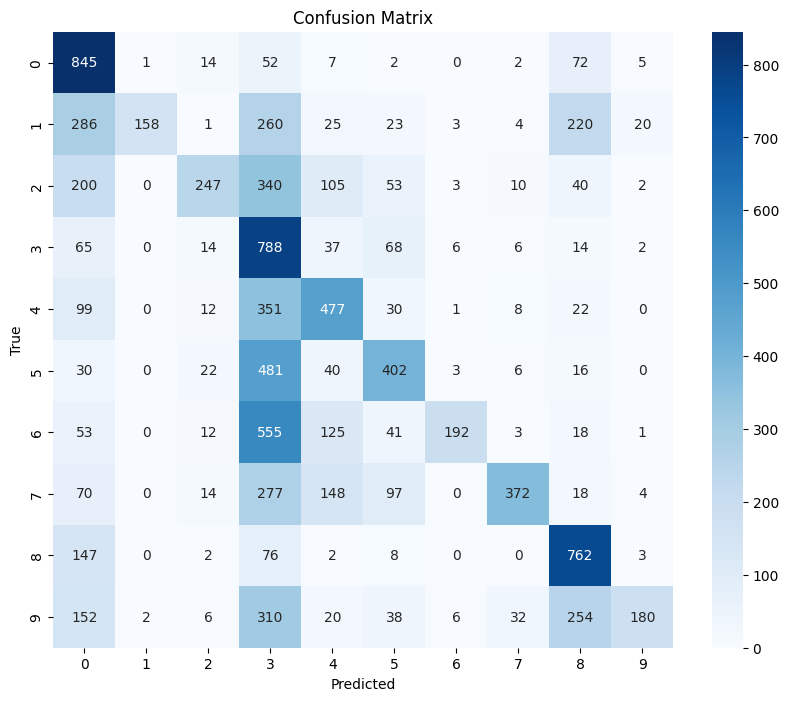

In [11]:
model.eval()
y_true = []
y_pred = []

for images, labels in testloader:
    images, labels = images.to(device), labels.to(device)
    outputs,_, _ = model2_finetune(images)
    _, preds = torch.max(outputs, 1)
    y_true.extend(labels.cpu().numpy())
    y_pred.extend(preds.cpu().numpy())

from sklearn.metrics import f1_score

print("Balanced Accuracy:", balanced_accuracy_score(y_true, y_pred))
print("Macro F1 Score:", f1_score(y_true, y_pred, average='macro'))

# Classification Report
print(classification_report(y_true, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=list(range(10)), yticklabels=list(range(10)))
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

Balanced Accuracy: 0.3465
Macro F1 Score: 0.30746573226296314
              precision    recall  f1-score   support

           0       0.47      0.36      0.41      1000
           1       0.91      0.09      0.16      1000
           2       0.31      0.39      0.35      1000
           3       0.23      0.69      0.35      1000
           4       0.36      0.31      0.33      1000
           5       0.45      0.33      0.38      1000
           6       0.80      0.18      0.29      1000
           7       0.95      0.16      0.28      1000
           8       0.32      0.92      0.47      1000
           9       0.90      0.03      0.05      1000

    accuracy                           0.35     10000
   macro avg       0.57      0.35      0.31     10000
weighted avg       0.57      0.35      0.31     10000



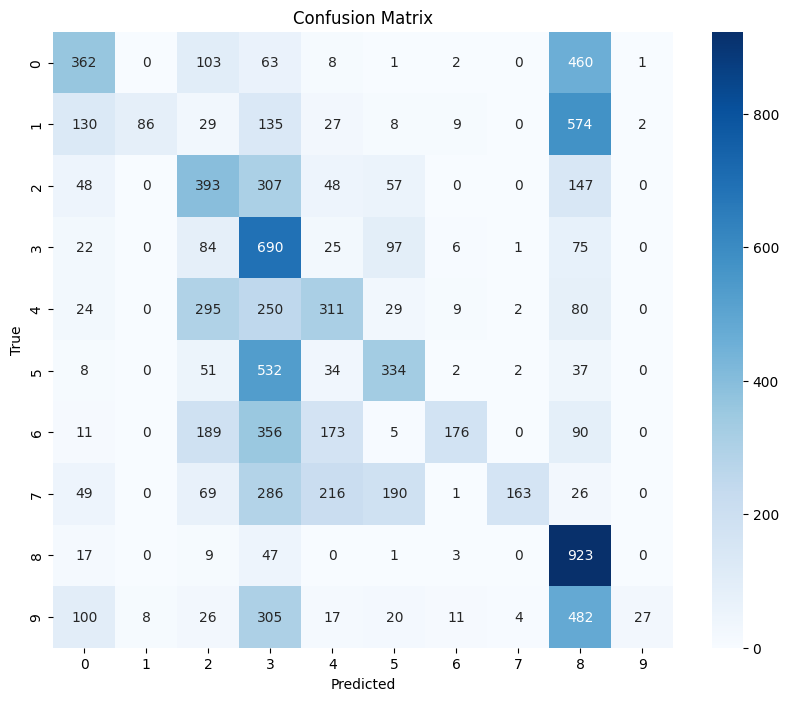

In [12]:
model.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

from sklearn.metrics import f1_score

print("Balanced Accuracy:", balanced_accuracy_score(y_true, y_pred))
print("Macro F1 Score:", f1_score(y_true, y_pred, average='macro'))

# Classification Report
print(classification_report(y_true, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=list(range(10)), yticklabels=list(range(10)))
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


In [16]:
from collections import defaultdict
import torch.nn.functional as F

def fgsm_attack(model, images, labels, epsilon, vdp=True):
    images.requires_grad = True
    if vdp:
        outputs, _, _ = model(images)
    else:
        outputs = model(images)
    loss = F.cross_entropy(outputs, labels)
    model.zero_grad()
    loss.backward()
    data_grad = images.grad.data
    perturbed = images + epsilon * data_grad.sign()
    return torch.clamp(perturbed, 0, 1)

def pgd_attack(model, images, labels, epsilon=0.03, alpha=0.007, num_iter=10, vdp=True):
    images = images.clone().detach().to(device)
    labels = labels.to(device)
    ori_images = images.clone().detach()

    for _ in range(num_iter):
        images.requires_grad = True
        if vdp:
            outputs, _, _ = model(images)
        else:
            outputs = model(images)
        loss = F.cross_entropy(outputs, labels)
        model.zero_grad()
        loss.backward()
        grad = images.grad.data

        # Update
        adv_images = images + alpha * grad.sign()
        # Project back into epsilon-ball
        eta = torch.clamp(adv_images - ori_images, min=-epsilon, max=epsilon)
        images = torch.clamp(ori_images + eta, min=0, max=1).detach()

    return images

def evaluate_classwise_accuracy(model, dataloader, epsilon=0.0, attack_type="clean", alpha=0.007, num_iter=10, vdp=True):
    model.eval()
    correct_per_class = defaultdict(int)
    total_per_class = defaultdict(int)


    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)
        if attack_type == "fgsm":
            images = fgsm_attack(model, images, labels, epsilon, vdp=vdp)
        elif attack_type == "pgd":
            images = pgd_attack(model, images, labels, epsilon, alpha, num_iter, vdp=vdp)

        if vdp:
            outputs, _, _ = model(images)
        else:
            outputs = model(images)
        _, preds = torch.max(outputs, 1)

        for label, pred in zip(labels, preds):
            total_per_class[label.item()] += 1
            if pred.item() == label.item():
                correct_per_class[label.item()] += 1

    acc = {c: correct_per_class[c] / total_per_class[c] for c in total_per_class}
    return acc


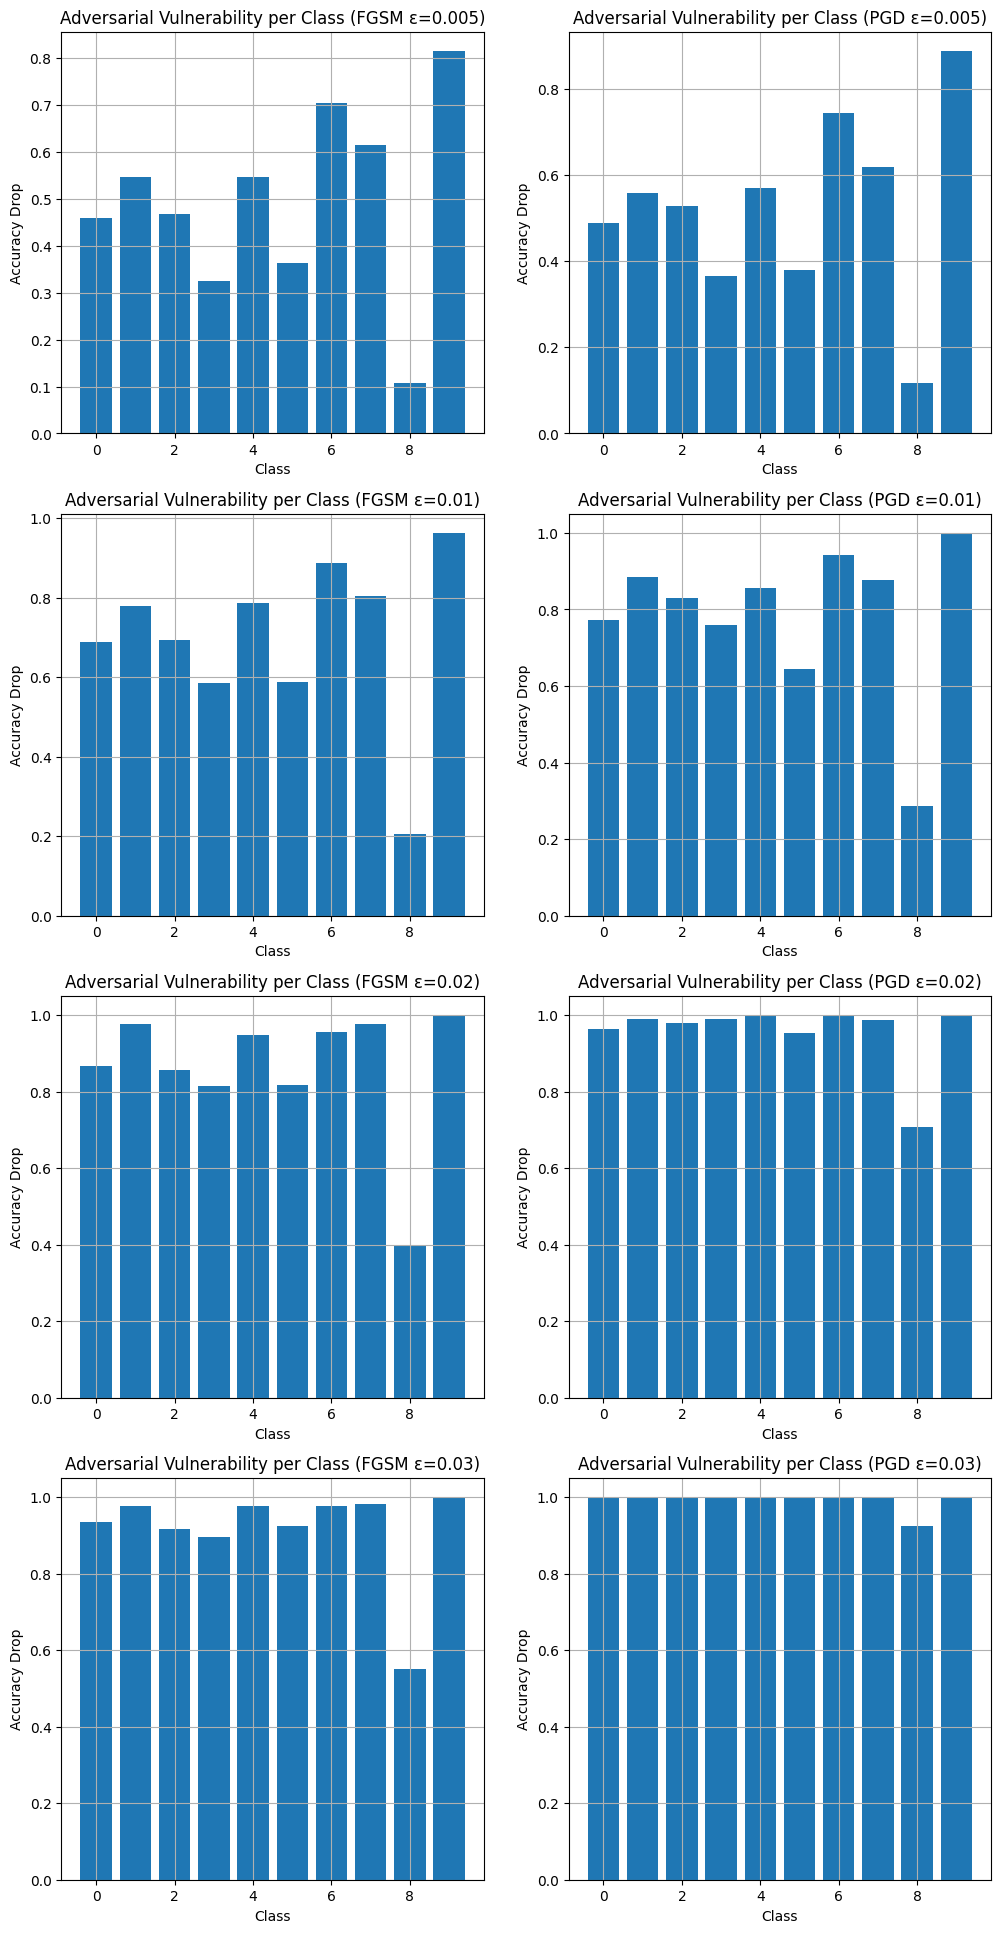

In [18]:
epsilons = [0.005, 0.01, 0.02, 0.03]
fig, axs = plt.subplots(len(epsilons), 2, figsize=(12,6*len(epsilons)))

for idx, epsilon in enumerate(epsilons):
    clean_acc = evaluate_classwise_accuracy(model, testloader, attack_type="clean", vdp=False)
    fgsm_acc = evaluate_classwise_accuracy(model, testloader, epsilon=epsilon, attack_type="fgsm", vdp=False)
    pgd_acc = evaluate_classwise_accuracy(model, testloader, epsilon=epsilon, attack_type="pgd", vdp=False)


    fgsm_drops = {c: (clean_acc[c] - fgsm_acc[c])/(clean_acc[c]+1e-9) for c in clean_acc}
    pgd_drops = {c: (clean_acc[c] - pgd_acc[c])/(clean_acc[c]+1e-9) for c in clean_acc}


    axs[idx, 0].bar(fgsm_drops.keys(), fgsm_drops.values())
    axs[idx, 0].set_xlabel("Class")
    axs[idx, 0].set_ylabel("Accuracy Drop")
    axs[idx, 0].set_title(f"Adversarial Vulnerability per Class (FGSM ε={epsilon})")
    axs[idx, 0].grid(True)

    axs[idx, 1].bar(pgd_drops.keys(), pgd_drops.values())
    axs[idx, 1].set_xlabel("Class")
    axs[idx, 1].set_ylabel("Accuracy Drop")
    axs[idx, 1].set_title(f"Adversarial Vulnerability per Class (PGD ε={epsilon})")
    axs[idx, 1].grid(True)



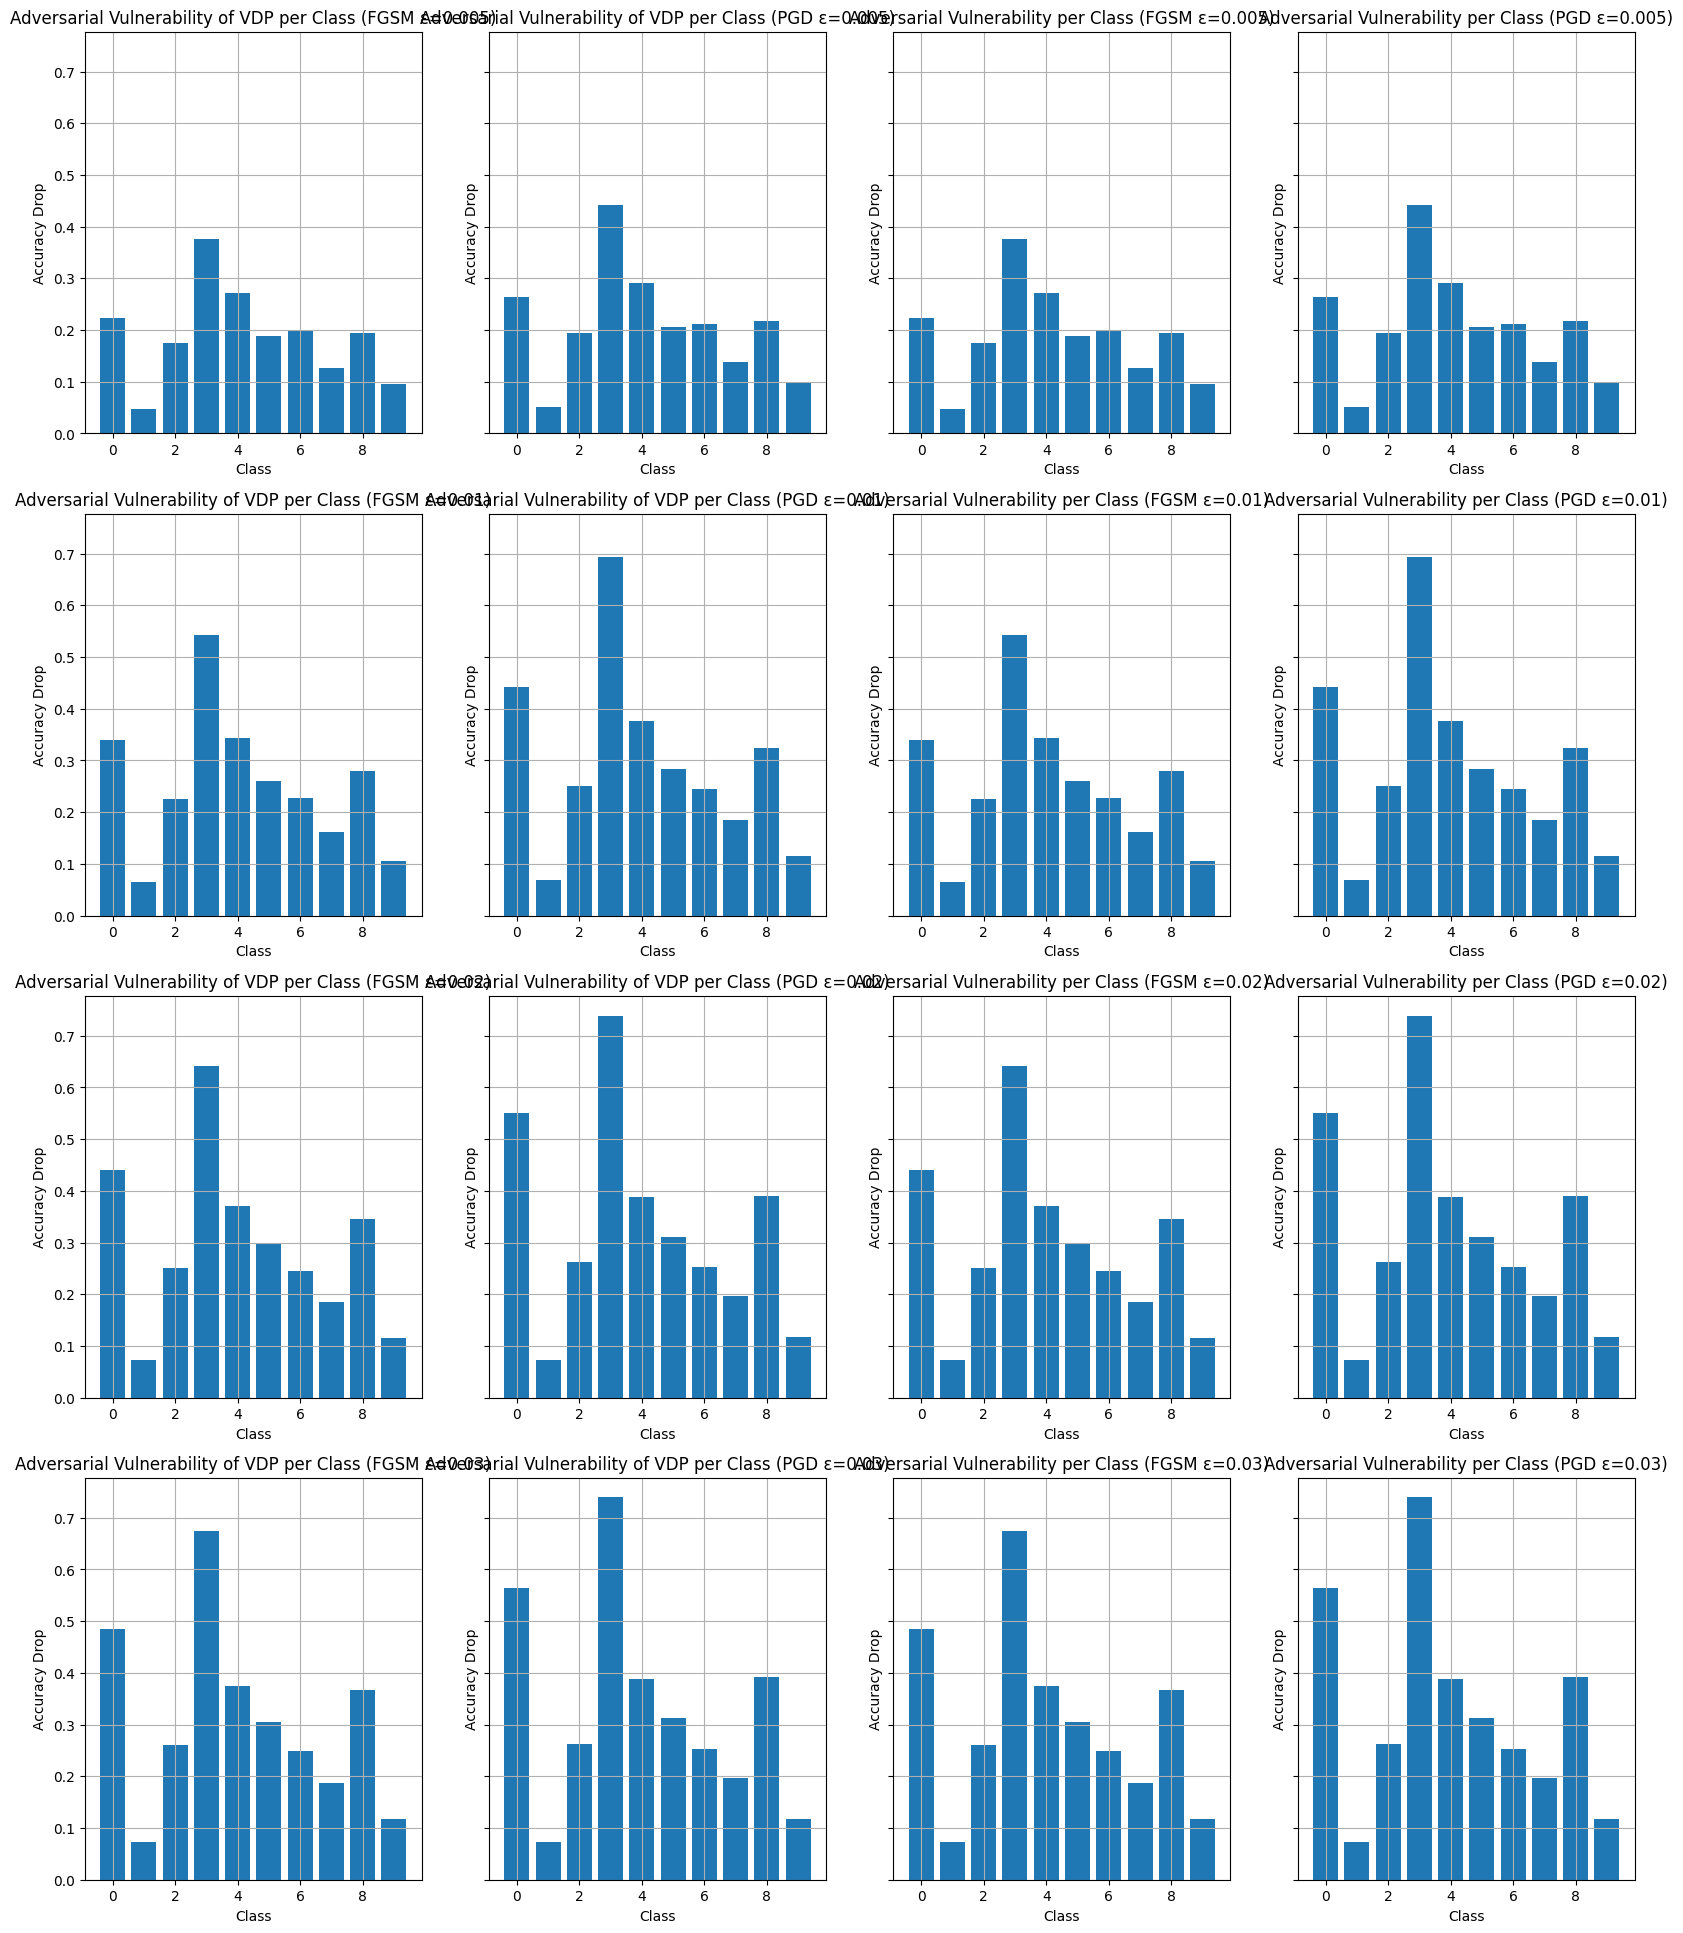

In [29]:
epsilons = [0.005, 0.01, 0.02, 0.03]
fig, axs = plt.subplots(len(epsilons), 4, figsize=(20,6*len(epsilons)), sharey=True)

for idx, epsilon in enumerate(epsilons):
    clean_acc_vdp = evaluate_classwise_accuracy(model2, testloader, attack_type="clean", vdp=True)
    fgsm_acc_vdp = evaluate_classwise_accuracy(model2, testloader, epsilon=epsilon, attack_type="fgsm", vdp=True)
    pgd_acc_vdp = evaluate_classwise_accuracy(model2, testloader, epsilon=epsilon, attack_type="pgd", vdp=True)

    clean_acc = evaluate_classwise_accuracy(model, testloader, attack_type="clean", vdp=False)
    fgsm_acc = evaluate_classwise_accuracy(model, testloader, epsilon=epsilon, attack_type="fgsm", vdp=False)
    pgd_acc = evaluate_classwise_accuracy(model, testloader, epsilon=epsilon, attack_type="pgd", vdp=False)


    fgsm_drops_vdp = {c: (clean_acc_vdp[c] - fgsm_acc_vdp[c]) for c in clean_acc_vdp}
    pgd_drops_vdp = {c: (clean_acc_vdp[c] - pgd_acc_vdp[c]) for c in clean_acc_vdp}


    fgsm_drops = {c: (clean_acc[c] - fgsm_acc[c]) for c in clean_acc}
    pgd_drops = {c: (clean_acc[c] - pgd_acc[c]) for c in clean_acc}


    axs[idx, 0].bar(fgsm_drops_vdp.keys(), fgsm_drops.values())
    axs[idx, 0].set_xlabel("Class")
    axs[idx, 0].set_ylabel("Accuracy Drop")
    axs[idx, 0].set_title(f"Adversarial Vulnerability of VDP per Class (FGSM ε={epsilon})")
    axs[idx, 0].grid(True)

    axs[idx, 1].bar(pgd_drops_vdp.keys(), pgd_drops.values())
    axs[idx, 1].set_xlabel("Class")
    axs[idx, 1].set_ylabel("Accuracy Drop")
    axs[idx, 1].set_title(f"Adversarial Vulnerability of VDP per Class (PGD ε={epsilon})")
    axs[idx, 1].grid(True)

    axs[idx, 2].bar(fgsm_drops.keys(), fgsm_drops.values())
    axs[idx, 2].set_xlabel("Class")
    axs[idx, 2].set_ylabel("Accuracy Drop")
    axs[idx, 2].set_title(f"Adversarial Vulnerability per Class (FGSM ε={epsilon})")
    axs[idx, 2].grid(True)

    axs[idx, 3].bar(pgd_drops.keys(), pgd_drops.values())
    axs[idx, 3].set_xlabel("Class")
    axs[idx, 3].set_ylabel("Accuracy Drop")
    axs[idx, 3].set_title(f"Adversarial Vulnerability per Class (PGD ε={epsilon})")
    axs[idx, 3].grid(True)


In [24]:

from collections import Counter

label_counts = Counter([label for _, label in trainset])
sorted_classes = sorted(label_counts.items(), key=lambda x: x[1], reverse=True)
head_classes = [c for c, _ in sorted_classes[:5]]  # e.g., top 5
tail_classes = [c for c, _ in sorted_classes[-5:]]  # bottom 5

head_acc = np.mean([class_acc[c] for c in head_classes])
tail_acc = np.mean([class_acc[c] for c in tail_classes])
print(f"Head class adversarial accuracy: {head_acc:.3f}")
print(f"Tail class adversarial accuracy: {tail_acc:.3f}")

# Assume you have clean_acc and adv_acc dictionaries
drops = {c: clean_acc[c] - adv_acc[c] for c in clean_acc}
plt.bar(drops.keys(), drops.values())
plt.xlabel("Class")
plt.ylabel("Accuracy Drop")
plt.title("Adversarial Vulnerability per Class")
plt.grid(True)
plt.show()




Head class adversarial accuracy: 0.103
Tail class adversarial accuracy: 0.064
